In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from scipy.sparse import csr_matrix
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import shap
import warnings
import gc

warnings.filterwarnings('ignore')

In [ ]:
# CONFIG Params
K_FOLDS = 5
NEG_TRAIN_SIZE = 1000       # negative patients per training fold
TOP_N = 50
RANDOM_STATE = 42
SHAP_ON_LAST_FOLD = True

rng = np.random.RandomState(RANDOM_STATE)

In [ ]:
# LOAD DATA
df = pd.read_parquet(r"MODEL_READY_MATRIX_NAMED_LABS.parquet")

print(f"Loaded matrix: {df.shape}")
print(f"  Label=1 (AD): {(df['LABEL']==1).sum()}")
print(f"  Label=0 (Control): {(df['LABEL']==0).sum()}")

feature_cols = [c for c in df.columns if c not in ['SUBJECT_ID', 'LABEL']]

pos_df = df[df['LABEL'] == 1].reset_index(drop=True)
neg_df = df[df['LABEL'] == 0].reset_index(drop=True)

n_pos = len(pos_df)
n_neg = len(neg_df)
print(f"\nPositive patients: {n_pos}")
print(f"Negative patients: {n_neg}")
print(f"Features: {len(feature_cols)}")

Loaded matrix: (46249, 6709)
  Label=1 (AD): 76
  Label=0 (Control): 46173

Positive patients: 76
Negative patients: 46173
Features: 6707


In [ ]:
# BUILD CUSTOM FOLDS
# 1. shuffle and partition positives into K equal folds
pos_indices = rng.permutation(n_pos)
pos_folds = np.array_split(pos_indices, K_FOLDS)

print(f"\nPositive fold sizes: {[len(f) for f in pos_folds]}")
print(f"Negative training size per fold: {NEG_TRAIN_SIZE}")

folds = []
for i in range(K_FOLDS):
    # positive test = fold i, positive train = everything else
    pos_test_idx = pos_folds[i]
    pos_train_idx = np.concatenate([pos_folds[j] for j in range(K_FOLDS) if j != i])

    # sample NEG_TRAIN_SIZE negatives for training
    neg_train_idx = rng.choice(n_neg, size=NEG_TRAIN_SIZE, replace=False)

    # remaining negatives = test
    neg_test_idx = np.setdiff1d(np.arange(n_neg), neg_train_idx)

    # oversample positive training to match negative training size
    if len(pos_train_idx) < NEG_TRAIN_SIZE:
        pos_train_idx_oversampled = resample(
            pos_train_idx,
            n_samples=NEG_TRAIN_SIZE,
            replace=True,
            random_state=RANDOM_STATE + i
        )
    else:
        pos_train_idx_oversampled = pos_train_idx

    # assemble actual dataframes
    train_pos = pos_df.iloc[pos_train_idx_oversampled]
    train_neg = neg_df.iloc[neg_train_idx]
    test_pos = pos_df.iloc[pos_test_idx]
    test_neg = neg_df.iloc[neg_test_idx]

    train = pd.concat([train_pos, train_neg], ignore_index=True)
    test = pd.concat([test_pos, test_neg], ignore_index=True)

    # shuffle
    train = train.sample(frac=1, random_state=RANDOM_STATE + i).reset_index(drop=True)
    test = test.sample(frac=1, random_state=RANDOM_STATE + i).reset_index(drop=True)

    X_tr = csr_matrix(train[feature_cols].values.astype(np.float32))
    y_tr = train['LABEL'].values
    X_te = csr_matrix(test[feature_cols].values.astype(np.float32))
    y_te = test['LABEL'].values

    folds.append({
        'X_train': X_tr, 'y_train': y_tr,
        'X_test': X_te, 'y_test': y_te,
    })

    print(f"  Fold {i}: train={len(train)} (pos={y_tr.sum()}, neg={len(y_tr)-y_tr.sum()}) | "
          f"test={len(test)} (pos={y_te.sum()}, neg={len(y_te)-y_te.sum()})")



Positive fold sizes: [16, 15, 15, 15, 15]
Negative training size per fold: 1000
  Fold 0: train=2000 (pos=1000, neg=1000) | test=45189 (pos=16, neg=45173)
  Fold 1: train=2000 (pos=1000, neg=1000) | test=45188 (pos=15, neg=45173)
  Fold 2: train=2000 (pos=1000, neg=1000) | test=45188 (pos=15, neg=45173)
  Fold 3: train=2000 (pos=1000, neg=1000) | test=45188 (pos=15, neg=45173)
  Fold 4: train=2000 (pos=1000, neg=1000) | test=45188 (pos=15, neg=45173)


In [ ]:
# HELPER: collect metrics
METRIC_NAMES = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

def print_cv_results(name, all_metrics):
    print(f"\n{name} Results (mean +/- std across folds):")
    for m in METRIC_NAMES:
        vals = np.array([d[m] for d in all_metrics])
        print(f"  {m}: {vals.mean():.4f} +/- {vals.std():.4f}")

In [ ]:
# DECISION TREE
print("\n" + "=" * 60)
print("DECISION TREE")
print("=" * 60)

dt_metrics = []
dt_importances_list = []
dt_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    dt = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
    dt.fit(fold['X_train'], fold['y_train'])

    y_pred = dt.predict(fold['X_test'])
    y_prob = dt.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    dt_metrics.append(m)
    dt_importances_list.append(dt.feature_importances_)
    dt_estimators.append(dt)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("Decision Tree", dt_metrics)

dt_importances = np.mean(dt_importances_list, axis=0)
dt_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_importances
}).sort_values('importance', ascending=False)
print(f"Non-zero importance features: {(dt_importances > 0).sum()}")


DECISION TREE
  Fold 1/5... AUC: 0.7336
  Fold 2/5... AUC: 0.7429
  Fold 3/5... AUC: 0.7372
  Fold 4/5... AUC: 0.5134
  Fold 5/5... AUC: 0.6955

Decision Tree Results (mean +/- std across folds):
  accuracy: 0.8203 +/- 0.0452
  f1: 0.0020 +/- 0.0007
  precision: 0.0010 +/- 0.0004
  recall: 0.5267 +/- 0.1744
  roc_auc: 0.6845 +/- 0.0872
Non-zero importance features: 70


In [ ]:
# LASSO (L1 LOGISTIC REGRESSION)
print("\n" + "=" * 60)
print("LASSO (L1 LOGISTIC REGRESSION)")
print("=" * 60)

lasso_metrics = []
lasso_coefs_list = []
lasso_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")

    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(fold['X_train'])
    X_te_scaled = scaler.transform(fold['X_test'])

    lasso = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=5000,
        C=1.0,
        random_state=RANDOM_STATE,
    )
    lasso.fit(X_tr_scaled, fold['y_train'])

    y_pred = lasso.predict(X_te_scaled)
    y_prob = lasso.predict_proba(X_te_scaled)[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    lasso_metrics.append(m)
    lasso_coefs_list.append(np.abs(lasso.coef_[0]))
    lasso_estimators.append((lasso, scaler))
    print(f"AUC: {m['roc_auc']:.4f}")

    del X_tr_scaled, X_te_scaled
    gc.collect()

print_cv_results("Lasso", lasso_metrics)

lasso_coefs = np.mean(lasso_coefs_list, axis=0)
lasso_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lasso_coefs
}).sort_values('importance', ascending=False)
print(f"Non-zero coefficient features: {(lasso_coefs > 0).sum()}")


LASSO (L1 LOGISTIC REGRESSION)
  Fold 1/5... AUC: 0.7314
  Fold 2/5... AUC: 0.7054
  Fold 3/5... AUC: 0.8660
  Fold 4/5... AUC: 0.8351
  Fold 5/5... AUC: 0.7168

Lasso Results (mean +/- std across folds):
  accuracy: 0.9561 +/- 0.0037
  f1: 0.0038 +/- 0.0015
  precision: 0.0019 +/- 0.0008
  recall: 0.2517 +/- 0.1001
  roc_auc: 0.7709 +/- 0.0663
Non-zero coefficient features: 960


In [ ]:
# RANDOM FOREST — BASELINE
print("\n" + "=" * 60)
print("RANDOM FOREST — BASELINE")
print("=" * 60)

rf_base_metrics = []
rf_base_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(fold['X_train'], fold['y_train'])

    y_pred = rf.predict(fold['X_test'])
    y_prob = rf.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    rf_base_metrics.append(m)
    rf_base_estimators.append(rf)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("Random Forest Baseline", rf_base_metrics)


RANDOM FOREST — BASELINE
  Fold 1/5... AUC: 0.7940
  Fold 2/5... AUC: 0.8163
  Fold 3/5... AUC: 0.8833
  Fold 4/5... AUC: 0.7384
  Fold 5/5... AUC: 0.8489

Random Forest Baseline Results (mean +/- std across folds):
  accuracy: 0.9691 +/- 0.0101
  f1: 0.0046 +/- 0.0013
  precision: 0.0023 +/- 0.0007
  recall: 0.2108 +/- 0.0984
  roc_auc: 0.8162 +/- 0.0492


In [ ]:
# RANDOM FOREST — HYPERPARAMETER TUNING (on fold 0 only)
print("\n" + "=" * 60)
print("RANDOM FOREST — HYPERPARAMETER TUNING")
print("=" * 60)

param_dist = {
    'n_estimators': randint(300, 2000),
    'max_depth': randint(5, 25),
    'min_samples_leaf': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

optimization_metric = 'recall'

# use fold 0's training data for the search
# internal CV for the search uses stratified k-fold on fold 0's training set
print("Running RandomizedSearchCV on fold 0 training data...")
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring=optimization_metric,
    cv=inner_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)
rf_search.fit(folds[0]['X_train'], folds[0]['y_train'])

print(f"\nBest {optimization_metric} from search: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")
best_rf_params = rf_search.best_params_

del rf_search
gc.collect()


RANDOM FOREST — HYPERPARAMETER TUNING
Running RandomizedSearchCV on fold 0 training data...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best recall from search: 1.0000
Best params: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 0.1, 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 1737}


344

In [ ]:
# RANDOM FOREST — TUNED, ALL FOLDS
print("\n" + "=" * 60)
print("RANDOM FOREST — TUNED (all folds)")
print("=" * 60)

rf_tuned_metrics = []
rf_tuned_estimators = []
rf_tuned_importances_list = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    rf_tuned = RandomForestClassifier(
        **best_rf_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_tuned.fit(fold['X_train'], fold['y_train'])

    y_pred = rf_tuned.predict(fold['X_test'])
    y_prob = rf_tuned.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    rf_tuned_metrics.append(m)
    rf_tuned_estimators.append(rf_tuned)
    rf_tuned_importances_list.append(rf_tuned.feature_importances_)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("Tuned Random Forest", rf_tuned_metrics)

rf_tuned_importances = np.mean(rf_tuned_importances_list, axis=0)
rf_tuned_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_tuned_importances
}).sort_values('importance', ascending=False)


RANDOM FOREST — TUNED (all folds)
  Fold 1/5... AUC: 0.8216
  Fold 2/5... AUC: 0.8224
  Fold 3/5... AUC: 0.8600
  Fold 4/5... AUC: 0.7291
  Fold 5/5... AUC: 0.8416

Tuned Random Forest Results (mean +/- std across folds):
  accuracy: 0.9511 +/- 0.0138
  f1: 0.0047 +/- 0.0027
  precision: 0.0024 +/- 0.0014
  recall: 0.3025 +/- 0.1230
  roc_auc: 0.8149 +/- 0.0452


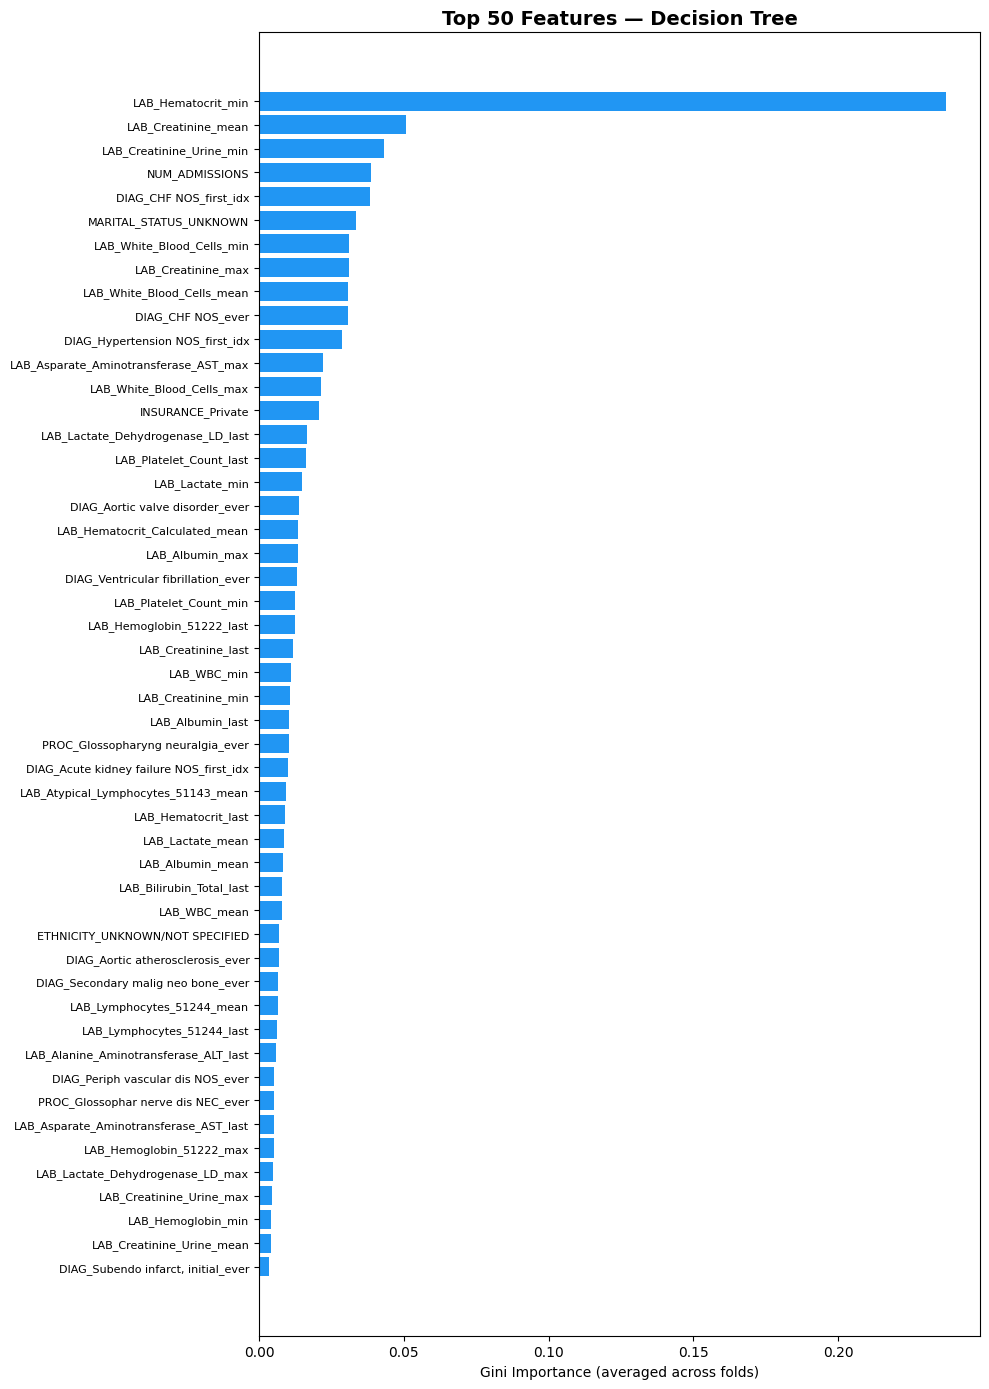

Saved: DT_Top50_Features.png


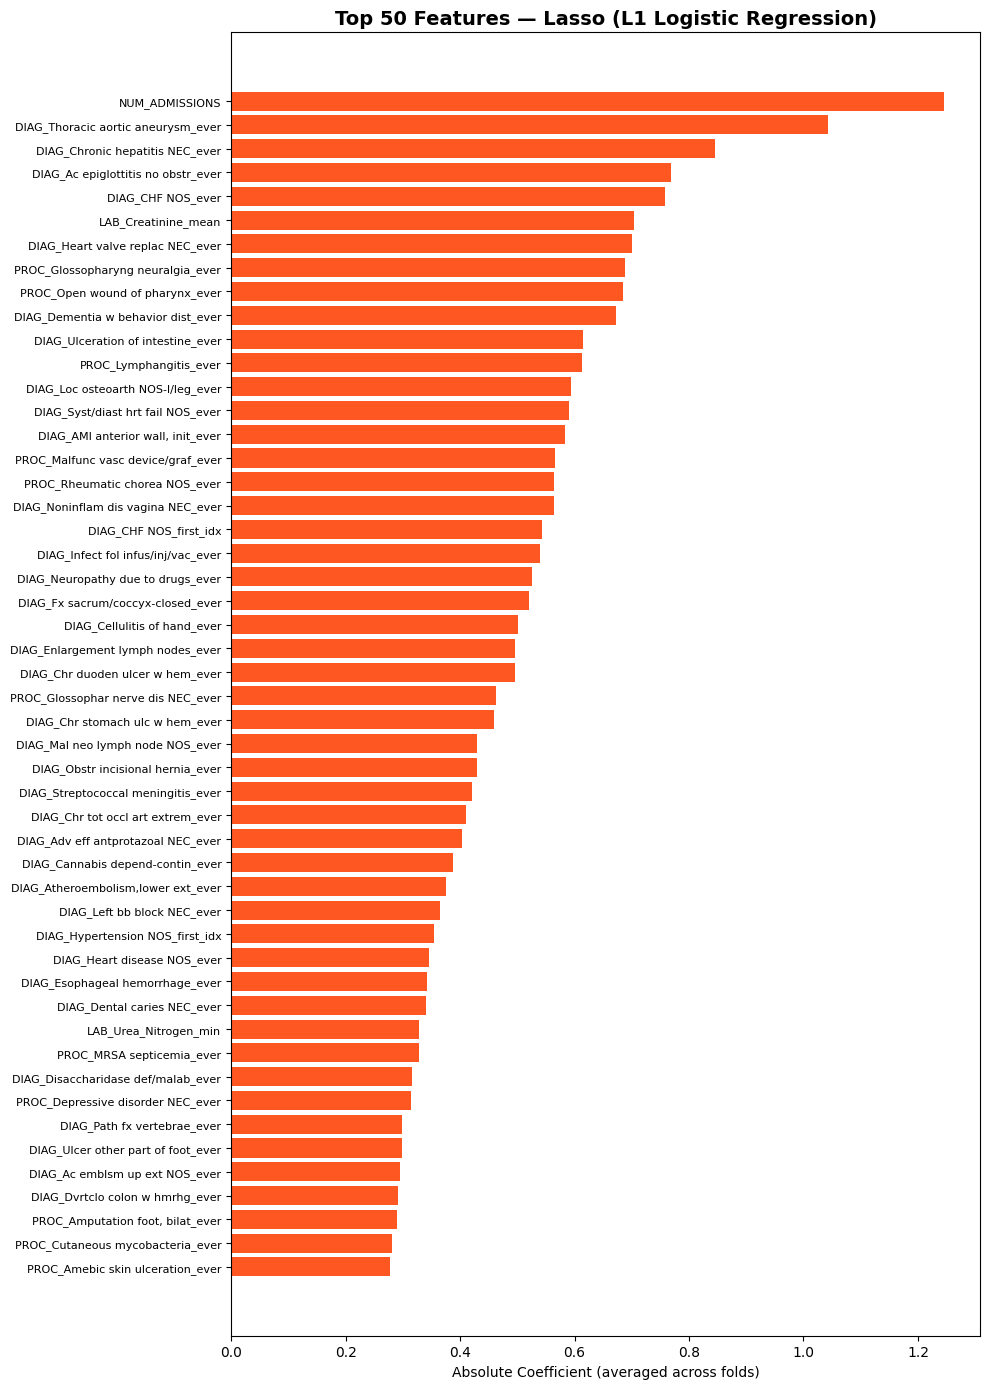

Saved: Lasso_Top50_Features.png


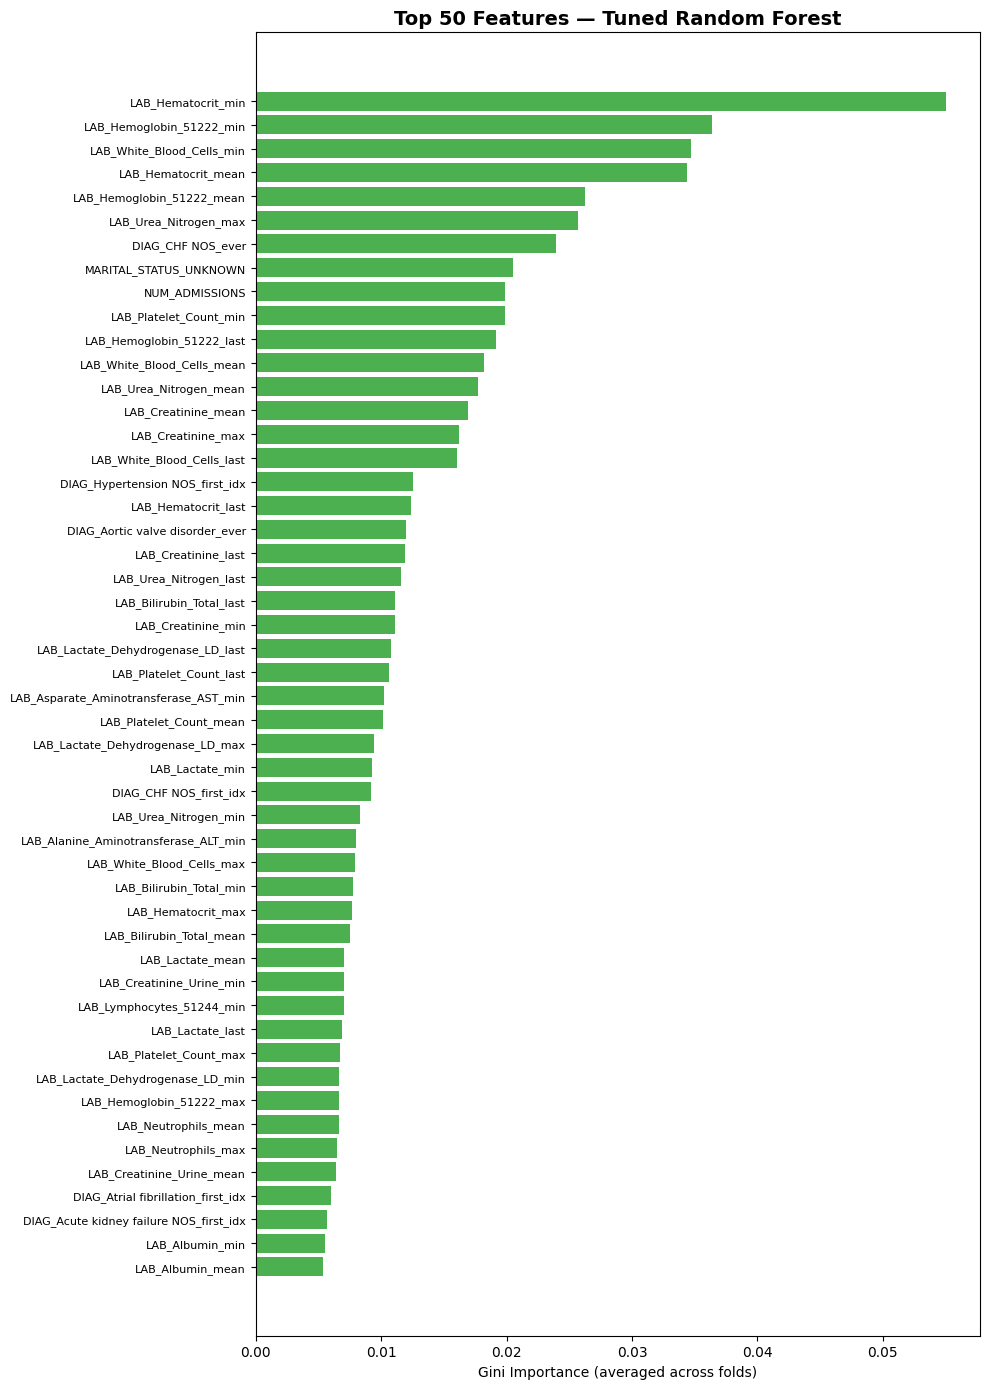

Saved: RF_Tuned_Top50_Features.png


In [ ]:
# FEATURE IMPORTANCE PLOTS

# Decision Tree
dt_top = dt_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(dt_top['feature'], dt_top['importance'], color='#2196F3')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Decision Tree', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"DT_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: DT_Top50_Features.png")

# Lasso
lasso_top = lasso_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(lasso_top['feature'], lasso_top['importance'], color='#FF5722')
ax.set_xlabel('Absolute Coefficient (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Lasso (L1 Logistic Regression)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"Lasso_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Lasso_Top50_Features.png")

# Tuned Random Forest
rf_top = rf_tuned_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(rf_top['feature'], rf_top['importance'], color='#4CAF50')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"RF_Tuned_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_Top50_Features.png")

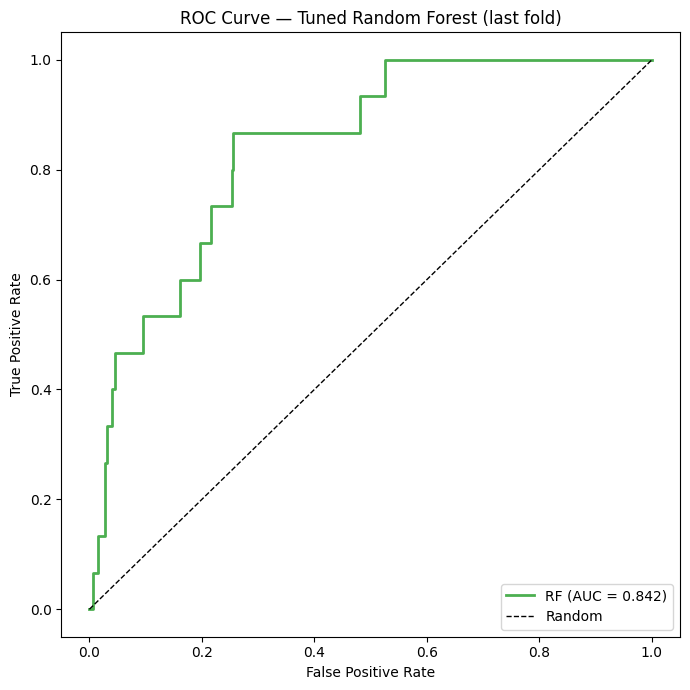

Saved: RF_Tuned_ROC.png


In [ ]:
# ROC CURVE — TUNED RF (last fold)
last_fold = folds[-1]
rf_last = rf_tuned_estimators[-1]

y_prob_last = rf_last.predict_proba(last_fold['X_test'])[:, 1]
fpr, tpr, _ = roc_curve(last_fold['y_test'], y_prob_last)
auc_val = roc_auc_score(last_fold['y_test'], y_prob_last)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='#4CAF50', lw=2, label=f'RF (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Random Forest (last fold)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"RF_Tuned_ROC.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_ROC.png")

In [ ]:
# SAVE ARTIFACTS FOR SHAP (run in separate notebook)
import pickle

print("\n" + "=" * 60)
print("SAVING SHAP ARTIFACTS TO DISK")
print("=" * 60)

# save the tuned RF estimator from last fold
with open("rf_last_fold_estimator.pkl", "wb") as f:
    pickle.dump(rf_last, f)
print("Saved: rf_last_fold_estimator.pkl")

# save test data as sparse + labels + feature names
from scipy.sparse import save_npz
save_npz("shap_X_test.npz", last_fold['X_test'])
np.save("shap_y_test.npy", last_fold['y_test'])
np.save("shap_feature_cols.npy", np.array(feature_cols))
print("Saved: shap_X_test.npz, shap_y_test.npy, shap_feature_cols.npy")


SAVING SHAP ARTIFACTS TO DISK
Saved: rf_last_fold_estimator.pkl
Saved: shap_X_test.npz, shap_y_test.npy, shap_feature_cols.npy


In [ ]:
# CLASSIFICATION REPORTS (last fold)
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS — Last Fold")
print("=" * 60)

# Decision Tree
print("\nDecision Tree:")
dt_pred = dt_estimators[-1].predict(last_fold['X_test'])
print(classification_report(last_fold['y_test'], dt_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], dt_pred))

# Lasso
print("\nLasso:")
lasso_last, scaler_last = lasso_estimators[-1]
X_te_scaled = scaler_last.transform(last_fold['X_test'])
lasso_pred = lasso_last.predict(X_te_scaled)
print(classification_report(last_fold['y_test'], lasso_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], lasso_pred))

# Tuned RF
print("\nTuned Random Forest:")
rf_pred = rf_last.predict(last_fold['X_test'])
print(classification_report(last_fold['y_test'], rf_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], rf_pred))


CLASSIFICATION REPORTS — Last Fold

Decision Tree:
              precision    recall  f1-score   support

     Control       1.00      0.83      0.91     45173
     Disease       0.00      0.60      0.00        15

    accuracy                           0.83     45188
   macro avg       0.50      0.71      0.45     45188
weighted avg       1.00      0.83      0.91     45188

Confusion Matrix:
[[37467  7706]
 [    6     9]]

Lasso:
              precision    recall  f1-score   support

     Control       1.00      0.96      0.98     45173
     Disease       0.00      0.33      0.01        15

    accuracy                           0.96     45188
   macro avg       0.50      0.65      0.49     45188
weighted avg       1.00      0.96      0.98     45188

Confusion Matrix:
[[43437  1736]
 [   10     5]]

Tuned Random Forest:
              precision    recall  f1-score   support

     Control       1.00      0.95      0.97     45173
     Disease       0.00      0.47      0.01        15

  

In [ ]:
# FEATURE OVERLAP ANALYSIS
print("\n" + "=" * 60)
print("FEATURE OVERLAP ANALYSIS")
print("=" * 60)

dt_top50_set = set(dt_importance_df.head(TOP_N)['feature'])
lasso_top50_set = set(lasso_importance_df.head(TOP_N)['feature'])
rf_top50_set = set(rf_tuned_importance_df.head(TOP_N)['feature'])

# DT vs Lasso
overlap_dt_lasso = dt_top50_set & lasso_top50_set
print(f"\nDT vs Lasso top {TOP_N}:")
print(f"  Shared: {len(overlap_dt_lasso)}")
print(f"  Only DT: {len(dt_top50_set - lasso_top50_set)}")
print(f"  Only Lasso: {len(lasso_top50_set - dt_top50_set)}")

# RF vs Lasso
overlap_rf_lasso = rf_top50_set & lasso_top50_set
print(f"\nRF vs Lasso top {TOP_N}:")
print(f"  Shared: {len(overlap_rf_lasso)}")
print(f"  Only RF: {len(rf_top50_set - lasso_top50_set)}")
print(f"  Only Lasso: {len(lasso_top50_set - rf_top50_set)}")

# All three
overlap_all = dt_top50_set & lasso_top50_set & rf_top50_set
print(f"\nAll three models top {TOP_N}:")
print(f"  Shared by all: {len(overlap_all)}")
for f in sorted(overlap_all):
    print(f"    {f}")

# Export
dt_importance_df.to_csv(r"DT_Feature_Importances.csv", index=False)
lasso_importance_df.to_csv(r"Lasso_Feature_Importances.csv", index=False)
rf_tuned_importance_df.to_csv(r"RF_Tuned_Feature_Importances.csv", index=False)
print("\nSaved all importance CSVs.")


FEATURE OVERLAP ANALYSIS

DT vs Lasso top 50:
  Shared: 7
  Only DT: 43
  Only Lasso: 43

RF vs Lasso top 50:
  Shared: 6
  Only RF: 44
  Only Lasso: 44

All three models top 50:
  Shared by all: 5
    DIAG_CHF NOS_ever
    DIAG_CHF NOS_first_idx
    DIAG_Hypertension NOS_first_idx
    LAB_Creatinine_mean
    NUM_ADMISSIONS

Saved all importance CSVs.
